# Exercise 4.A Introduction to Linear Regression

In [9]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [10]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [11]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [12]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores: ', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores:  [np.float64(84.6), np.float64(55.9)]


In [13]:
r_squared = model.score(X_test, y_test)
print(f'R**2 score: {r_squared:.3f}')

R**2 score: 0.998


### R**2 means that it is calculating the higher scores obtained by students that study longer. 

### 0.998 tells me the highest decimal percentage of the highest scores. 

### Hours studied predicts higher test scores in a good way because the moreyou study the material, the better you are at retaining it and passing the tests. 

C:\Users\disco\New folder\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


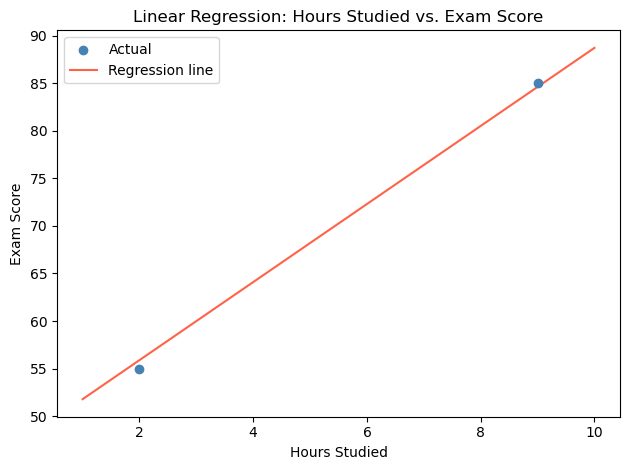

In [14]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
X['hours_studied'].min(),
X['hours_studied'].max(),
100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

### The data points follow the regression line closely because they are very much compatible. The longer a student studies, the higher test scores they receive on the exam. This matches the r**2 variable closely because that produced the percentage of the highest scores by students who studied for so long. 

## Lab 2
### Building your own model

In [15]:
ad_data = {
'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}

In [16]:
df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [19]:
X2 = df_ads[['monthly_ad_spend']]
print(X2.shape)

print("==============================")

y2 = df_ads['monthly_revenue']
print(y2.shape)

(20, 1)
(20,)


In [23]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
print(X2_train)
print(X2_test)

    monthly_ad_spend
8               4500
5               3000
11              6000
3               2000
18              9500
16              8500
13              7000
2               1500
9               5000
19             10000
4               2500
12              6500
7               4000
10              5500
14              7500
6               3500
    monthly_ad_spend
0                500
17              9000
15              8000
1               1000


In [29]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
print('Model trained successfully.')

Model trained successfully.


In [30]:
print(f'\nSlope (coefficient): {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}')

# For each additional dollar of monthly_ad_spend, the predicted monthly_revenue increases by 1.96. 


Slope (coefficient): 1.96
Intercept: 3625.89


### Making predictions and evaluating the model

In [36]:
y2_pred = model2.predict(X2_test)
print('Actual revenue: ', list(y2_test))
print('Predicted revenue: ', list(y2_pred.round(1)))

Actual revenue:  [4200, 21500, 19400, 5100]
Predicted revenue:  [np.float64(4603.8), np.float64(21229.0), np.float64(19273.1), np.float64(5581.8)]


In [38]:
r_squared = model2.score(X2_test, y2_test)
print(f'R**2 score: {r_squared:.3f}')

R**2 score: 0.998


#### 0.998 is a good fit as a score because it shows the highest percentage of scores achieved within the class by students who spend a majority of their time studying the material being covered within the exams they are taking. The r_squared score of 0.998 means that 99.8% of the variation in monthly revenue is explained by monthly ad spend. This indicates the model is a very good fit for the data. 

### Visualizing the results

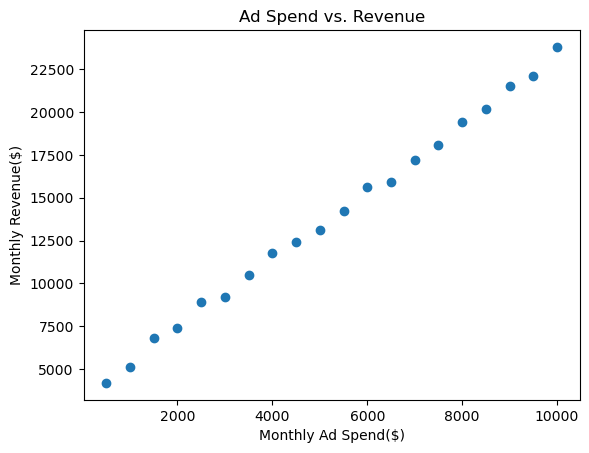

In [43]:
plt.scatter(X2, y2)
plt.title('Ad Spend vs. Revenue')
plt.xlabel('Monthly Ad Spend($)')
plt.ylabel('Monthly Revenue($)')
plt.show()

C:\Users\disco\New folder\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


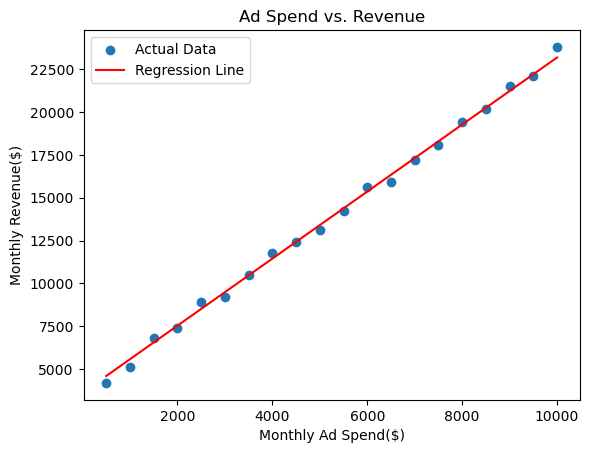

In [49]:
plt.scatter(X2, y2, label = 'Actual Data')
x_range = np.linspace(X2['monthly_ad_spend'].min(), X2['monthly_ad_spend'].max(), 100).reshape(-1,1)
y_line = model2.predict(x_range)
plt.plot(x_range, y_line, color = 'red', label = 'Regression Line')
plt.title('Ad Spend vs. Revenue')
plt.xlabel('Monthly Ad Spend($)')
plt.ylabel('Monthly Revenue($)')
label = plt.legend()
plt.show()

The Regression Line does fits the data well visually because it matches what the r_squared score had told me, which is that there is an upwards trend in the amount of revenue gained from the ads that the company pays for. 